# Set up

In [45]:
%run ../../../setup_workspace.py # ../ means level up 
import scipy

✓ Workspace ready


# Data

In [46]:
path = r"E:\Sirius Samples\Subcheva\ga_fnp_1m_0_00000_2D_sum_azimAvg_sub.dat"
data = pd.read_table(path, header=None, names=['q', 'I', 'error'], 
                      engine='python', skiprows=160, sep = r'\s+', encoding='UTF-8')

q = data['q']*10
I = data['I']

# Functions

In [47]:
def Polydisperse_spheres(x, scale, Ravg, p, bkg):
    global counter 
    global sigma
    sigma = p*Ravg
    R = np.arange(max((Ravg - 3*sigma), 0.00001), Ravg + 3*sigma, 0.05)
    Iq = []
    for i in x:
        f = (Gaussian(R, sigma, Ravg) * (R**6)) * ((3*(np.sin(i*R) - i*R*np.cos(i*R))/(i*R)**3)**2) 
        Iq.append(scale * scipy.integrate.cumulative_trapezoid(f, R, dx = None, axis = 0)[-1] + bkg)
    return Iq

# Analysis

In [81]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6

In [89]:
fit = pd.read_table(r"E:\Sirius Samples\Subcheva\Fit_core_shell.txt", sep=str(' '), names=['q', 'I'], skiprows=1)
fit

,q,I
0,0.027353,4.259882e+07
1,0.027659,4.185816e+07
2,0.027965,4.112124e+07
3,0.028270,4.039066e+07
4,0.028576,3.966185e+07
...,...,...
1058,0.350704,4.402255e+05
1059,0.351009,4.402199e+05
1060,0.351315,4.402143e+05
1061,0.351621,4.402087e+05


array([1.07085863e+03, 5.80473571e+00, 1.80886612e-01, 4.95188081e+05])

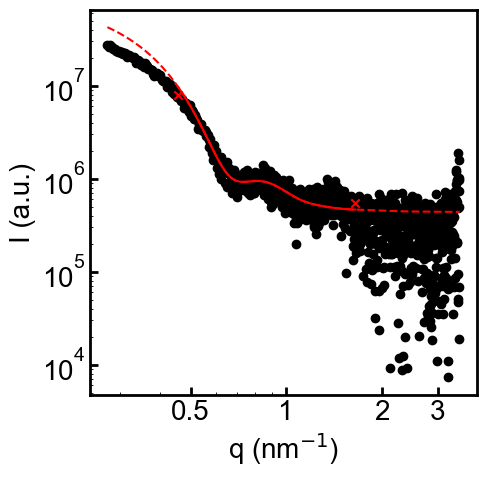

In [97]:
fig, ax = plt.subplots(1,1, figsize=(5,5))

plt.semilogx()
plt.semilogy()
plt.xlabel('q / nm')
plt.ylabel('I / a.u.')
plt.scatter(q, I, color='black')

l, r = 60, 450

plt.scatter([q[l], q[r]], [I[l], I[r]], marker='x', color='r', zorder=10)

# p, cov = curve_fit(Polydisperse_spheres, q[l:r], I[l:r], p0=[3.42123520e+02, 6, 0.08, 3.73970289e1])
# plt.plot(q[l:r], Polydisperse_spheres(q[l:r], *p), color='red', label='FF (R = 5.8 nm)')
# plt.plot(q, Polydisperse_spheres(q, *p), color='red', linestyle='--')

plt.plot(fit['q'][l:r] *10, fit['I'][l:r], color='red')
plt.plot(fit['q'] * 10, fit['I'], color='red', linestyle='--')

plt.xlabel('q (nm$^{-1}$)', fontname='Arial', fontsize=20)  # ← Markdown для степени
plt.ylabel('I (a.u.)', fontname='Arial', fontsize=20)

#plt.legend(frameon=False, fontsize=12)

ax.tick_params(axis='both', which='major', labelsize=15)

ax.set_xticks([0.5, 1, 2, 3])
ax.get_xaxis().set_major_formatter(plt.FormatStrFormatter('%g'))

# Set Arial font for tick labels
ax.tick_params(axis='both', which='major', labelsize=20)
for tick in ax.get_xticklabels():
    tick.set_fontname('Arial')
for tick in ax.get_yticklabels():
    tick.set_fontname('Arial')
    
#ax.legend()
p

In [68]:
pd.DataFrame({'q':q/10, 'I':I}).to_csv(r"E:\Sirius Samples\Subcheva\res_q.dat", sep=str('\t'), index=False)